## 1. read 2D point cloud

In [470]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

df = pd.read_csv(r'output_zhang.csv', encoding='utf-8', header=None, low_memory=False)
data = df.to_numpy()
print(data.shape)
print('----------------------')
print(data)

(19656, 2)
----------------------
[[  27.2021  796.    ]
 [  27.3395  796.    ]
 [  27.4823  796.    ]
 ...
 [  65.0281 1602.    ]
 [  65.1379 1609.    ]
 [  65.2643 1617.    ]]


## 2. split all data to each scan 

In [471]:
num_scan = 1 # 1 scan = 360 degree
num_beam = 0 # 1 beam = 0.12 degree
previous_degree = 0 # meaningless
scan_split = [0]

print('---------- {} time scan ----------'.format(num_scan))
for beam in data:
    # each scan
    # if int(previous_degree) != 0 and int(beam[0]) == 0: 
    if int(previous_degree) - int(beam[0]) > 2: 
        scan_split.append(num_beam)
        num_scan += 1
        print('---------- {} time scan ----------'.format(num_scan))
    previous_degree = beam[0]

    num_beam += 1

scan_split.append(data.shape[0])
print('scan_split:', scan_split)

all_data = []
for i in range(len(scan_split)-1):
    all_data.append(data[scan_split[i] : scan_split[i+1]])

---------- 1 time scan ----------
---------- 2 time scan ----------
---------- 3 time scan ----------
---------- 4 time scan ----------
---------- 5 time scan ----------
---------- 6 time scan ----------
---------- 7 time scan ----------
---------- 8 time scan ----------
---------- 9 time scan ----------
---------- 10 time scan ----------
---------- 11 time scan ----------
---------- 12 time scan ----------
---------- 13 time scan ----------
---------- 14 time scan ----------
---------- 15 time scan ----------
---------- 16 time scan ----------
---------- 17 time scan ----------
---------- 18 time scan ----------
---------- 19 time scan ----------
---------- 20 time scan ----------
---------- 21 time scan ----------
---------- 22 time scan ----------
---------- 23 time scan ----------
---------- 24 time scan ----------
---------- 25 time scan ----------
---------- 26 time scan ----------
---------- 27 time scan ----------
---------- 28 time scan ----------
---------- 29 time scan -----

## 3. traverse each scan (real time)

### 3.1 (ascend) angle range decision
![image](./ascend2.jpg)

In [472]:
"""
just example



# given
h = 710
d_min = 400
d_max = 6000

# calculate
min_theta = np.arctan(d_min/h)
min_theta = min_theta*180/np.pi

max_theta = np.arctan(d_max/h)
max_theta = max_theta*180/np.pi

print('min angle:', int(min_theta))
print('max angle:', int(max_theta))


"""

min angle: 29
max angle: 83


### 3.2 (ascend) step detection

#### 3.2.1 (ascend) denoise/smooth

##### SMA (Simple Moving Average): Y = (Yt + Yt-1 + Yt-2 + Yt-3 + Yt-4)/5 （pandas: dataframe.rolling(n).mean()）
##### WMA (Weighted Moving Average): Y = (5Yt + 4Yt-1 + 3Yt-2 + 2Yt-3 + 1Yt-4) /(5+4+3+2+1) （custom function）
##### EMA (Exponential Moving Average): 与WMA算法相似, 但多了一个平滑系a＝2/(n+1) （custom function）
##### FM (Median Filter): 与SMA算法相似只不过变成了中位数, (scipy.signal.medfilt(dataframe, n))
##### SGF (Savitzky-Golay Filter): 是一种多项式最小二乘法拟合的滤波法, 特点是平降噪同时保持原信号形状和宽度不变, 
![image](./SG_Filter.jpg)

In [473]:
"""
just algorithm example



# original
data = {'x':["2019-12-01","2019-12-02","2019-12-03","2019-12-04","2019-12-05",
             "2019-12-06","2019-12-07","2019-12-08","2019-12-09","2019-12-10",
             "2019-12-11","2019-12-12","2019-12-13","2019-12-14","2019-12-15",
             "2019-12-16","2019-12-17","2019-12-18","2019-12-19","2019-12-20"],
        'y':[100, 110, 95, 97, 103, 114, 127, 120, 113, 119, 90, 94, 108, 101, 97, 115, 124, 102, 106, 99]
}
df = pd.DataFrame(data)
# SMA
df['SMA(3)'] = df['y'].rolling(3).mean().round(1)
df['SMA(5)'] = df['y'].rolling(5).mean().round(1)
df['SMA(7)'] = df['y'].rolling(7).mean().round(1)
print(df)
# visualization
plt.plot(df['x'], df['y'], label='y')
plt.plot(df['x'], df['SMA(3)'], 'k--', label='SMA(3)')
plt.plot(df['x'], df['SMA(5)'], 'r--', label='SMA(5)')
plt.plot(df['x'], df['SMA(7)'], 'g--', label='SMA(7)')
plt.xticks(rotation=90)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
# WMA
def wma(y):
    weights = np.arange(len(y)) + 1
    wma = np.sum(weights * y) / weights.sum()
    return wma
df['WMA(3)'] = df['y'].rolling(3).apply(wma, raw=True).round(1)
df['WMA(5)'] = df['y'].rolling(5).apply(wma, raw=True).round(1)
df['WMA(7)'] = df['y'].rolling(7).apply(wma, raw=True).round(1)
print(df)
# visualization
plt.plot(df['x'], df['y'], label='y')
plt.plot(df['x'], df['WMA(3)'], 'k--', label='WMA(3)')
plt.plot(df['x'], df['WMA(5)'], 'r--', label='WMA(5)')
plt.plot(df['x'], df['WMA(7)'], 'g--', label='WMA(7)')
plt.xticks(rotation=90)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
# EMA
def ema(y, n):
    ema = np.zeros(len(y))
    ema[:] = np.nan # initial via NAN
    ema[n-1] = y[:n].mean() # only calculate the head part via SMA
    for i in range(n, len(y)):
        ema[i] = ema[i-1] + (y[i] - ema[i-1]) / (n + 1) * 2
    return ema
df['EMA(3)'] = ema(df['y'], 3).round(1)
df['EMA(5)'] = ema(df['y'], 5).round(1)
df['EMA(7)'] = ema(df['y'], 7).round(1)
print(df)
# visualization
plt.plot(df['x'], df['y'], label='y')
plt.plot(df['x'], df['EMA(3)'], 'k--', label='EMA(3)')
plt.plot(df['x'], df['EMA(5)'], 'r--', label='EMA(5)')
plt.plot(df['x'], df['EMA(7)'], 'g--', label='EMA(7)')
plt.xticks(rotation=90)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
# FM    
df['FM(3)'] = signal.medfilt(df['y'], 3)
df['FM(5)'] = signal.medfilt(df['y'], 5)
df['FM(7)'] = signal.medfilt(df['y'], 7)
print(df)
# visualization
plt.plot(df['x'], df['y'], label='y')
plt.plot(df['x'], df['FM(3)'], 'k--', label='FM(3)')
plt.plot(df['x'], df['FM(5)'], 'r--', label='FM(5)')
plt.plot(df['x'], df['FM(7)'], 'g--', label='FM(7)')
plt.xticks(rotation=90)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
# SGF
k = 3 # polyorder为对窗口内数据进行k阶多项式拟合, 因此k要小于window_size
df['SGF(5)'] = signal.savgol_filter(df['y'], 5, k, mode='nearest')
df['SGF(7)'] = signal.savgol_filter(df['y'], 7, k, mode='nearest')
df['SGF(9)'] = signal.savgol_filter(df['y'], 9, k, mode='nearest')
print(df)
# visualization
plt.plot(df['x'], df['y'], label='y')
plt.plot(df['x'], df['SGF(5)'], 'k--', label='SGF(5)')
plt.plot(df['x'], df['SGF(7)'], 'r--', label='SGF(7)')
plt.plot(df['x'], df['SGF(9)'], 'g--', label='SGF(9)')
plt.xticks(rotation=90)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()



"""

'\njust algorithm example\n\n\n\n# original\ndata = {\'x\':["2019-12-01","2019-12-02","2019-12-03","2019-12-04","2019-12-05",\n             "2019-12-06","2019-12-07","2019-12-08","2019-12-09","2019-12-10",\n             "2019-12-11","2019-12-12","2019-12-13","2019-12-14","2019-12-15",\n             "2019-12-16","2019-12-17","2019-12-18","2019-12-19","2019-12-20"],\n        \'y\':[100, 110, 95, 97, 103, 114, 127, 120, 113, 119, 90, 94, 108, 101, 97, 115, 124, 102, 106, 99]\n}\ndf = pd.DataFrame(data)\n# SMA\ndf[\'SMA(3)\'] = df[\'y\'].rolling(3).mean().round(1)\ndf[\'SMA(5)\'] = df[\'y\'].rolling(5).mean().round(1)\ndf[\'SMA(7)\'] = df[\'y\'].rolling(7).mean().round(1)\nprint(df)\n# visualization\nplt.plot(df[\'x\'], df[\'y\'], label=\'y\')\nplt.plot(df[\'x\'], df[\'SMA(3)\'], \'k--\', label=\'SMA(3)\')\nplt.plot(df[\'x\'], df[\'SMA(5)\'], \'r--\', label=\'SMA(5)\')\nplt.plot(df[\'x\'], df[\'SMA(7)\'], \'g--\', label=\'SMA(7)\')\nplt.xticks(rotation=90)\nplt.xlabel(\'x\')\nplt.ylabel(\'

#### 3.2.2 (ascend) find inflection point

### 3.3 (ascend) step height & step distance's calculation sample
![image](./ascend.jpg)

In [474]:
"""
just algorithm example



# given
h = 710
d = 1650
theta = 71
theta = theta*np.pi/180

# calculate
h1 = d * np.cos(theta)
h2 = h - h1
d1 = d * np.sin(theta)
d2 = d1

print('step height:', int(h2))
print('step distance:', int(d2))


"""


"\njust algorithm example\n\n\n\n# given\nh = 710\nd = 1650\ntheta = 71\ntheta = theta*np.pi/180\n\n# calculate\nh1 = d * np.cos(theta)\nh2 = h - h1\nd1 = d * np.sin(theta)\nd2 = d1\n\nprint('step height:', int(h2))\nprint('step distance:', int(d2))\n\n\n"

### code of "all 3.2 (ascend) step detection"

---------- 1 time scan ----------
all data: 378
error data: 22
!!! STEP FOUND AHEAD !!!
Angle:70.5927, Distance:1634.0
Step Height: 167, Step Distance: 1541


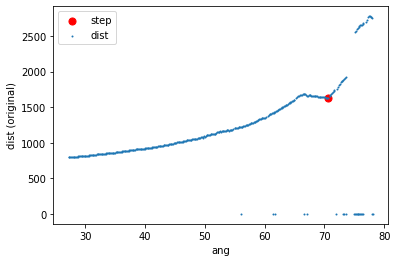




---------- 2 time scan ----------
all data: 378
error data: 23
!!! STEP FOUND AHEAD !!!
Angle:70.686, Distance:1646.0
Step Height: 165, Step Distance: 1553


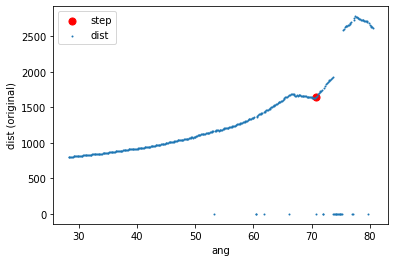




---------- 3 time scan ----------
all data: 378
error data: 27
!!! STEP FOUND AHEAD !!!
Angle:70.6091, Distance:1638.0
Step Height: 166, Step Distance: 1545


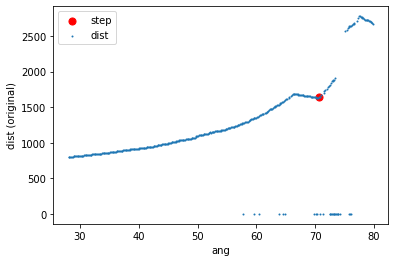




---------- 4 time scan ----------
all data: 378
error data: 29
!!! STEP FOUND AHEAD !!!
Angle:70.5432, Distance:1636.0
Step Height: 165, Step Distance: 1542


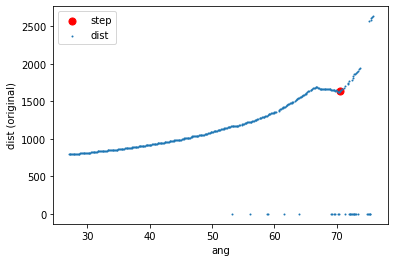




---------- 5 time scan ----------
all data: 378
error data: 7
~~~ NO STEP AHEAD ~~~
---------- 6 time scan ----------
all data: 378
error data: 5
~~~ NO STEP AHEAD ~~~
---------- 7 time scan ----------
all data: 378
error data: 1
~~~ NO STEP AHEAD ~~~
---------- 8 time scan ----------
all data: 378
error data: 0
~~~ NO STEP AHEAD ~~~
---------- 9 time scan ----------
all data: 378
error data: 1
~~~ NO STEP AHEAD ~~~
---------- 10 time scan ----------
all data: 378
error data: 1
~~~ NO STEP AHEAD ~~~
---------- 11 time scan ----------
all data: 378
error data: 2
~~~ NO STEP AHEAD ~~~
---------- 12 time scan ----------
all data: 378
error data: 4
~~~ NO STEP AHEAD ~~~
---------- 13 time scan ----------
all data: 378
error data: 1
~~~ NO STEP AHEAD ~~~
---------- 14 time scan ----------
all data: 378
error data: 2
~~~ NO STEP AHEAD ~~~
---------- 15 time scan ----------
all data: 378
error data: 2
~~~ NO STEP AHEAD ~~~
---------- 16 time scan ----------
all data: 378
error data: 4
~~~ 

In [496]:
h = 710
window_size = 7
k = 3 # k-th order polynomial of SGF (should less than window_size)
gradient_window_size = 10 # number of continuous distance gradients (to find inflection point) (!!must be even!!)
gradient_threshold = 0 # decide gradient boundary (to find inflection point)
if_visual = False


for i, scan_data in enumerate(all_data):
    print('---------- {} time scan ----------'.format(i+1))
    print('all data: {}'.format(len(scan_data)))

    ##### number of error data #####
    num_error = 0
    for beam_data in scan_data:
        if beam_data[1] == 0:
            num_error += 1
    print('error data: {}'.format(num_error))
    
    if if_visual:
        ##### original scan data #####
        # plt.xlim((50, 55)) # degree
        # plt.ylim((1300, 1900)) # distance
        plt.scatter(scan_data[:, 0], scan_data[:, 1], s=1, label='dist')
        plt.xlabel('ang')
        plt.ylabel('dist (original)')
        plt.legend()
        plt.show()

    ##### non-error scan data #####
    data = scan_data[scan_data[:, 1]!=0]


    ########## denoise/smooth ##########
    # original (non-error)
    df = pd.DataFrame(data = data, columns=['ang', 'dist'])
    # SMA
    # df['SMA({})'.format(window_size)] = df['dist'].rolling(window_size).mean().round(2)
    # WMA
    # df['WMA({})'.format(window_size)] = df['dist'].rolling(window_size).apply(wma, raw=True).round(2)
    # EMA
    # df['EMA({})'.format(window_size)] = ema(df['dist'], window_size).round(2) 
    # FM
    df['FM({})'.format(window_size)] = signal.medfilt(df['dist'], window_size).round(2) 
    # SGF
    # df['SGF({})'.format(window_size)] = signal.savgol_filter(df['dist'], window_size, k, mode='nearest') 

    if if_visual:
        plt.plot(df['ang'], df['dist'], label='dist') # original (non-error)
        plt.plot(df['ang'], df['SMA({})'.format(window_size)], 'g--', label='SMA({})'.format(window_size)) # SMA
        plt.plot(df['ang'], df['WMA({})'.format(window_size)], 'r--', label='WMA({})'.format(window_size)) # WMA
        plt.plot(df['ang'], df['EMA({})'.format(window_size)], 'y--', label='EMA({})'.format(window_size)) # EMA
        plt.plot(df['ang'], df['FM({})'.format(window_size)], 'k--', label='FM({})'.format(window_size)) # FM
        plt.plot(df['ang'], df['SGF({})'.format(window_size)], 'c--', label='SGF({})'.format(window_size)) # SGF
        plt.axvline(x=66, color='r', linestyle='--')
        plt.axvline(x=71, color='r', linestyle='--')
        # plt.xlim((65, 75))
        # plt.ylim((1550, 1750))
        plt.xlabel('angle')
        plt.ylabel('dist')
        plt.legend()
        plt.show()


    ########## !!! use/not use smoothing !!! ##########
    # SMA
    # data = np.hstack((df['ang'].to_numpy()[:, np.newaxis], df['SMA({})'.format(window_size)].to_numpy()[:, np.newaxis]))
    # WMA
    # data = np.hstack((df['ang'].to_numpy()[:, np.newaxis], df['WMA({})'.format(window_size)].to_numpy()[:, np.newaxis]))
    # EMA
    # data = np.hstack((df['ang'].to_numpy()[:, np.newaxis], df['EMA({})'.format(window_size)].to_numpy()[:, np.newaxis]))
    # FM
    data = np.hstack((df['ang'].to_numpy()[:, np.newaxis], df['FM({})'.format(window_size)].to_numpy()[:, np.newaxis])) # best for skewness
    # SGF
    # data = np.hstack((df['ang'].to_numpy()[:, np.newaxis], df['SGF({})'.format(window_size)].to_numpy()[:, np.newaxis]))


    ########## find inflection point ##########
    ##### get gradient #####
    diffs = []
    for i in range(len(data)-1):
        # diffs.append([non_0_scan_data[i][0], non_0_scan_data[i+1][1] - non_0_scan_data[i][1]]) # subtraction
        # diffs.append([non_0_scan_data[i][0], non_0_scan_data[i+1][1] / non_0_scan_data[i][1]]) # division
        diffs.append([ data[i][0], (data[i+1][1] - data[i][1]) / (data[i+1][0] - data[i][0]) ]) # gradient

    diffs = np.array(diffs)

    ##### decision via mean gradient #####
    mean_i1_2_i10 = []
    mean_i10_2_i20 = []

    inflection_points = []

    for i, (ang, dist_diffs) in enumerate(diffs):
        if (i+2*gradient_window_size) > len(diffs): # prevent moving window overflow
            break

        i1_2_i10 = diffs[i : i+gradient_window_size][:, 1]
        i10_2_i20 = diffs[i+gradient_window_size : i+2*gradient_window_size][:, 1]
        
        mean_i1_2_i10.append(i1_2_i10.mean())
        mean_i10_2_i20.append(i10_2_i20.mean())
        if i1_2_i10.mean() < gradient_threshold and i10_2_i20.mean() > gradient_threshold:
            # angle, distance, distance gradient
            inflection_points.append([  data[i+gradient_window_size][0], data[i+gradient_window_size][1], diffs[i+gradient_window_size][1]  ]) ##### inflection point(s)

    if if_visual:
        plt.scatter(diffs[:, 0], diffs[:, 1], s=1, label='dist') # gradient
        mean_i10_2_i20_start = int(gradient_window_size*1.5 - 1)
        mean_i10_2_i20_end = int(-(gradient_window_size/2))
        plt.plot(diffs[:, 0][mean_i10_2_i20_start:mean_i10_2_i20_end], mean_i10_2_i20, 'g-', label='mean grad') # mean of 10-20 gradients window
        # plt.xlim((0, 90))
        plt.ylim((-150, 150)) 
        plt.xlabel('angle')
        plt.ylabel('dist diffs')
        plt.legend()
        plt.axhline(y=0, color='r', linestyle='--')
        plt.axvline(x=66, color='r', linestyle='--')
        plt.axvline(x=71, color='r', linestyle='--')
        plt.show()

    ##### only use the last inflection point #####
    if len(inflection_points) == 0:
        print('~~~ NO STEP AHEAD ~~~')
        continue

    ##### only use the last inflection point #####
    infle_ang, infle_dist, infle_dist_diff = inflection_points[-1]
    print('!!! STEP FOUND AHEAD !!!')
    print('Angle:{}, Distance:{}'.format(infle_ang, infle_dist)) ########## !!! final inflection point !!! ##########


    ########## calculate step height(h2) & step distance(d2) ##########
    ##### given #####
    d = infle_dist
    theta = infle_ang
    theta = theta * np.pi / 180

    ##### calculate h2 & d2 #####
    h1 = d * np.cos(theta)
    h2 = h - h1
    d1 = d * np.sin(theta)
    d2 = d1
    print('Step Height: {}, Step Distance: {}'.format(int(h2), int(d2)))


    if True:
        ##### original scan data #####
        # plt.xlim((50, 55)) # degree
        # plt.ylim((1300, 1900)) # distance
        if len(inflection_points) != 0:
            plt.scatter(infle_ang, infle_dist, s=50, c='r', label='step') # inflection point

        plt.scatter(scan_data[:, 0], scan_data[:, 1], s=1, label='dist')
        plt.xlabel('ang')
        plt.ylabel('dist (original)')
        plt.legend()
        plt.show()


    print()
    print()
    print()



    # break

#### (descend) calculation sample of step height & step distance 

In [497]:
"""
just example



height = 710 # mm
width = 3000
step = 75
diff_degree = 1 # sampling

##### on the step
C = np.sqrt(height**2 + width**2)
print('short hypotenuse: {:.2f}'.format(C))

radian = np.arctan(height/width)
degree = radian * 180/np.pi
print('degree: {:.2f}'.format(degree))


##### under the step
long_height = height + step
long_C = long_height/np.sin(radian)
print('long hypotenuse: {:.2f}'.format(long_C))

# difference
diff = long_C - C 
print('difference (long & original): {:.2f}'.format(diff))


##### on the step (before step boundary)
small_degree = degree + diff_degree
print('small degree: {:.2f}'.format(small_degree))

small_radian = small_degree * np.pi/180
short_C = height / np.sin(small_radian)

# difference
diff2 = C - short_C
print('difference (original & short): {:.2f}'.format(diff2))


"""

"\njust example\n\n\n\nheight = 710 # mm\nwidth = 3000\nstep = 75\ndiff_degree = 1 # sampling\n\n##### on the step\nC = np.sqrt(height**2 + width**2)\nprint('short hypotenuse: {:.2f}'.format(C))\n\nradian = np.arctan(height/width)\ndegree = radian * 180/np.pi\nprint('degree: {:.2f}'.format(degree))\n\n\n##### under the step\nlong_height = height + step\nlong_C = long_height/np.sin(radian)\nprint('long hypotenuse: {:.2f}'.format(long_C))\n\n# difference\ndiff = long_C - C \nprint('difference (long & original): {:.2f}'.format(diff))\n\n\n##### on the step (before step boundary)\nsmall_degree = degree + diff_degree\nprint('small degree: {:.2f}'.format(small_degree))\n\nsmall_radian = small_degree * np.pi/180\nshort_C = height / np.sin(small_radian)\n\n# difference\ndiff2 = C - short_C\nprint('difference (original & short): {:.2f}'.format(diff2))\n\n\n"